# 🏦 Credit Risk Predictor — Week 3: SHAP Explainability

**Goal:** Explain WHY the model flags a loan as risky — not just give a score.

**Inputs:** `xgb_credit_risk.pkl` + `train_processed.csv` from Week 2 (in Drive)

---
### Why this matters
A bank can't just say "the AI said no" — regulators and customers need a reason.
SHAP (SHapley Additive exPlanations) breaks down each prediction into
**individual feature contributions** — exactly which factors pushed the risk score up or down.

### Plan
1. Load model + data
2. Global feature importance (SHAP summary plot)
3. Individual prediction explanation (waterfall plot)
4. Compare a low-risk vs high-risk applicant
5. Build a plain-English explanation generator
6. Business impact calculation

In [1]:
# ── CELL 1: Mount Drive & Install packages ─────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

!pip install shap xgboost -q

print('✓ Drive mounted')
print('✓ Packages ready')

Mounted at /content/drive
✓ Drive mounted
✓ Packages ready


In [2]:
# ── CELL 2: Imports ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('✓ All libraries loaded')
print(f'SHAP version: {shap.__version__}')

✓ All libraries loaded
SHAP version: 0.52.0


---
## Step 1 — Load Model and Data

In [3]:
# ── CELL 3: Load model, features, and data ─────────────────────────────────
MODEL_PATH    = '/content/drive/MyDrive/xgb_credit_risk.pkl'
FEATURES_PATH = '/content/drive/MyDrive/selected_features.pkl'
DATA_PATH     = '/content/drive/MyDrive/train_processed.csv'

with open(MODEL_PATH, 'rb') as f:
    model = pickle.load(f)

with open(FEATURES_PATH, 'rb') as f:
    SELECTED_FEATURES = pickle.load(f)

df = pd.read_csv(DATA_PATH)
X = df[SELECTED_FEATURES]
y = df['TARGET']

# Recreate the same test split as Week 2 (same random_state)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✓ Model loaded')
print(f'✓ Features  : {len(SELECTED_FEATURES)} columns')
print(f'✓ Test set  : {X_test.shape}')
print(f'\nModel type: {type(model).__name__}')

✓ Model loaded
✓ Features  : 84 columns
✓ Test set  : (61503, 84)

Model type: XGBClassifier


---
## Step 2 — Build the SHAP Explainer

For tree-based models like XGBoost, `TreeExplainer` is fast and exact —
it computes SHAP values by analysing the actual tree structure, not by sampling.

In [4]:
# ── CELL 4: Create SHAP explainer ──────────────────────────────────────────
print('Building SHAP TreeExplainer...')
explainer = shap.TreeExplainer(model)

# Use a sample of the test set for speed (SHAP on 60K rows is slow)
SAMPLE_SIZE = 2000
X_sample = X_test.sample(SAMPLE_SIZE, random_state=42)

print(f'Computing SHAP values for {SAMPLE_SIZE:,} sample loans...')
shap_values = explainer(X_sample)

print('✓ SHAP values computed')
print(f'  Shape: {shap_values.values.shape}')
print(f'  Base value (average prediction): {shap_values.base_values[0]:.4f}')

Building SHAP TreeExplainer...
Computing SHAP values for 2,000 sample loans...
✓ SHAP values computed
  Shape: (2000, 84)
  Base value (average prediction): 0.0141


---
## Step 3 — Global Feature Importance (SHAP Summary)

This is the **most important chart in your whole project.**

Unlike XGBoost's built-in importance (which just counts splits), SHAP shows:
- **Which direction** each feature pushes (red = increases risk, blue = decreases risk)
- **How much** each feature matters on average
- **The spread** — how differently it affects different people

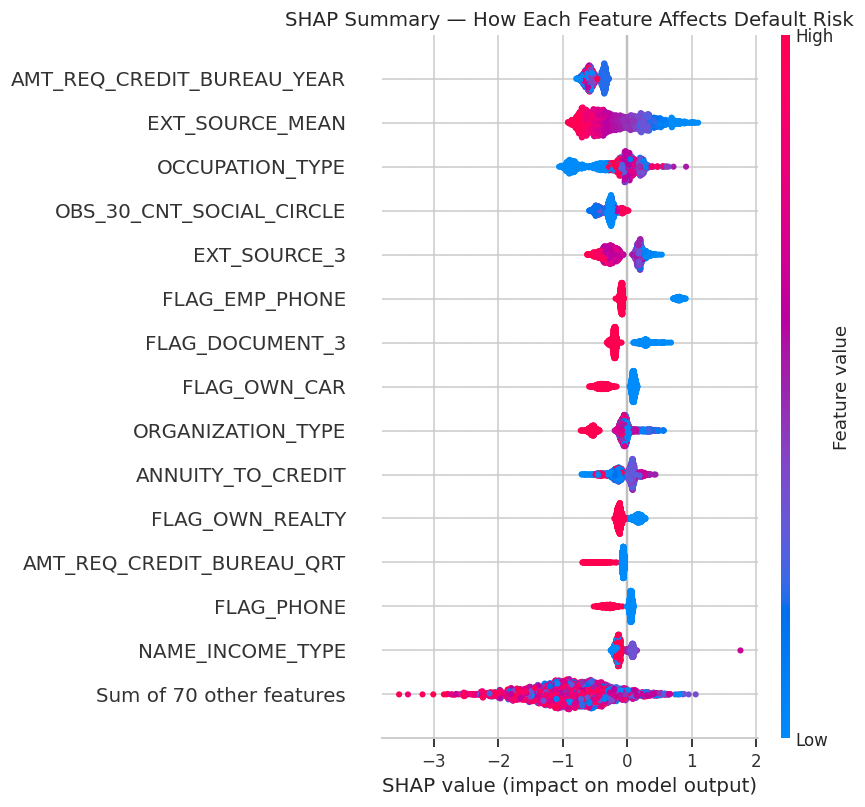

How to read this chart:
  • Each dot = one loan applicant
  • Position on x-axis = how much that feature pushed risk up (right) or down (left)
  • Red = high feature value, Blue = low feature value
  • Features sorted by overall importance (top = most important)


In [5]:
# ── CELL 5: SHAP summary (beeswarm) plot ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Summary — How Each Feature Affects Default Risk', fontsize=13)
plt.tight_layout()
plt.savefig('/content/shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

print('How to read this chart:')
print('  • Each dot = one loan applicant')
print('  • Position on x-axis = how much that feature pushed risk up (right) or down (left)')
print('  • Red = high feature value, Blue = low feature value')
print('  • Features sorted by overall importance (top = most important)')

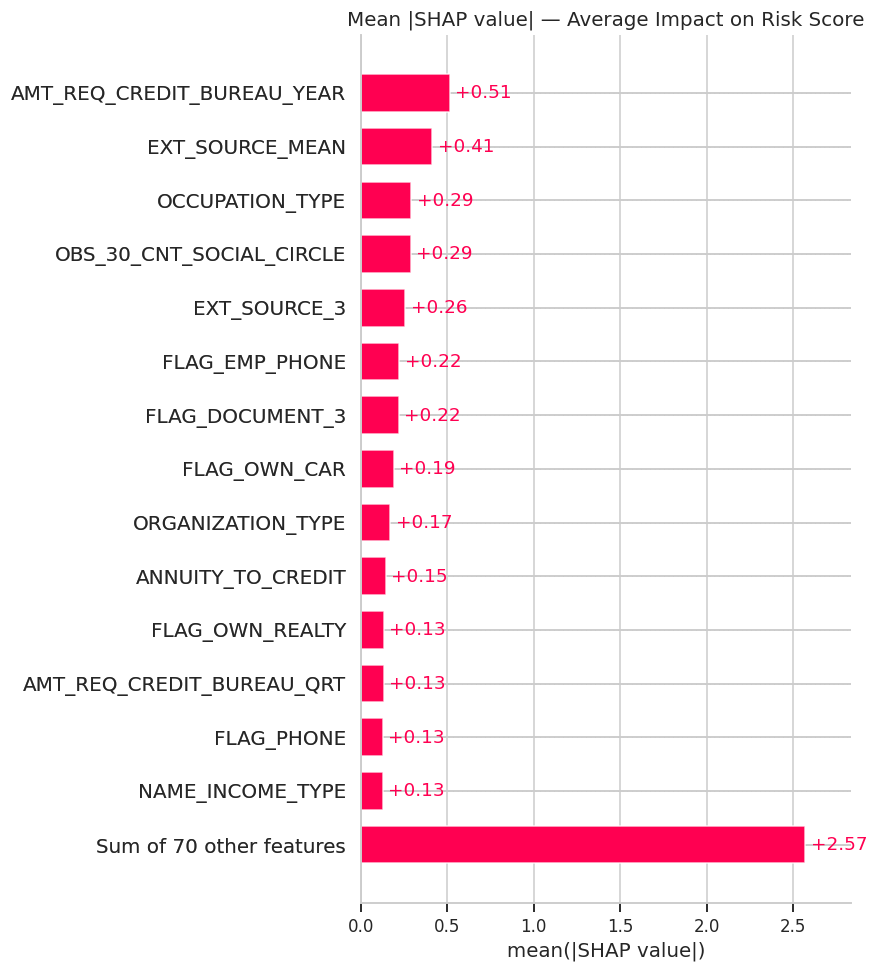

Top 10 most important features (by SHAP):
  AMT_REQ_CREDIT_BUREAU_YEAR   0.5146
  EXT_SOURCE_MEAN              0.4149
  OCCUPATION_TYPE              0.2930
  OBS_30_CNT_SOCIAL_CIRCLE     0.2919
  EXT_SOURCE_3                 0.2594
  FLAG_EMP_PHONE               0.2242
  FLAG_DOCUMENT_3              0.2232
  FLAG_OWN_CAR                 0.1940
  ORGANIZATION_TYPE            0.1720
  ANNUITY_TO_CREDIT            0.1468


In [6]:
# ── CELL 6: SHAP bar chart — mean absolute impact ──────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('Mean |SHAP value| — Average Impact on Risk Score', fontsize=13)
plt.tight_layout()
plt.savefig('/content/shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

# Print top 10 as text for the README
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': SELECTED_FEATURES,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print('Top 10 most important features (by SHAP):')
for i, row in importance_df.head(10).iterrows():
    print(f'  {row["feature"]:<28} {row["mean_abs_shap"]:.4f}')

---
## Step 4 — Individual Prediction Explanations (Waterfall Plots)

This is what goes in your **Streamlit app** — explaining one specific applicant's score.

We'll look at:
1. A **high-risk** applicant — what pushed their score up?
2. A **low-risk** applicant — what kept their score down?

In [7]:
# ── CELL 7: Find a high-risk and low-risk applicant ────────────────────────
probs_sample = model.predict_proba(X_sample)[:, 1]

high_risk_idx = np.argmax(probs_sample)
low_risk_idx  = np.argmin(probs_sample)

print(f'High-risk applicant:')
print(f'  Index in sample : {high_risk_idx}')
print(f'  Default probability: {probs_sample[high_risk_idx]*100:.1f}%')
print(f'  Actual outcome  : {"Defaulted" if y_test.iloc[X_sample.index[high_risk_idx] - X_test.index[0]] == 1 else "Repaid"}' if False else '')

print(f'\nLow-risk applicant:')
print(f'  Index in sample : {low_risk_idx}')
print(f'  Default probability: {probs_sample[low_risk_idx]*100:.1f}%')

High-risk applicant:
  Index in sample : 953
  Default probability: 63.1%


Low-risk applicant:
  Index in sample : 1832
  Default probability: 0.4%


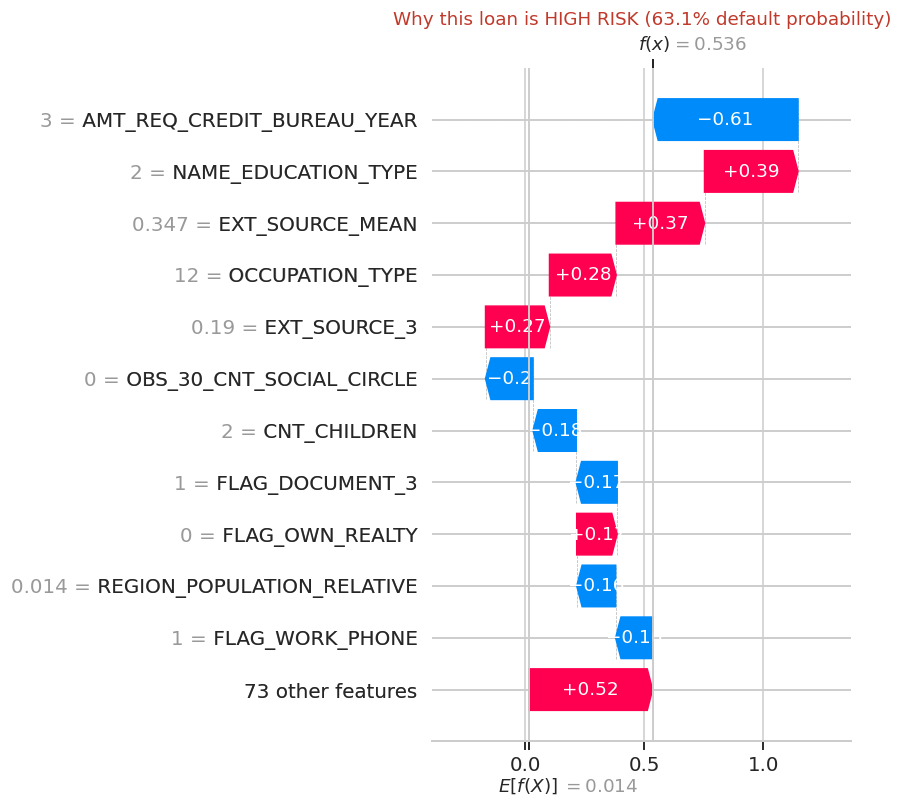

How to read this:
  • Starts at the base value (average risk across all loans)
  • Red bars push the prediction RIGHT (higher risk)
  • Blue bars push the prediction LEFT (lower risk)
  • Final position (right edge) = this applicant's predicted risk


In [8]:
# ── CELL 8: Waterfall plot — HIGH RISK applicant ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(shap_values[high_risk_idx], max_display=12, show=False)
plt.title(f'Why this loan is HIGH RISK ({probs_sample[high_risk_idx]*100:.1f}% default probability)',
          fontsize=12, color='#C0392B')
plt.tight_layout()
plt.savefig('/content/shap_high_risk.png', dpi=120, bbox_inches='tight')
plt.show()

print('How to read this:')
print('  • Starts at the base value (average risk across all loans)')
print('  • Red bars push the prediction RIGHT (higher risk)')
print('  • Blue bars push the prediction LEFT (lower risk)')
print('  • Final position (right edge) = this applicant\'s predicted risk')

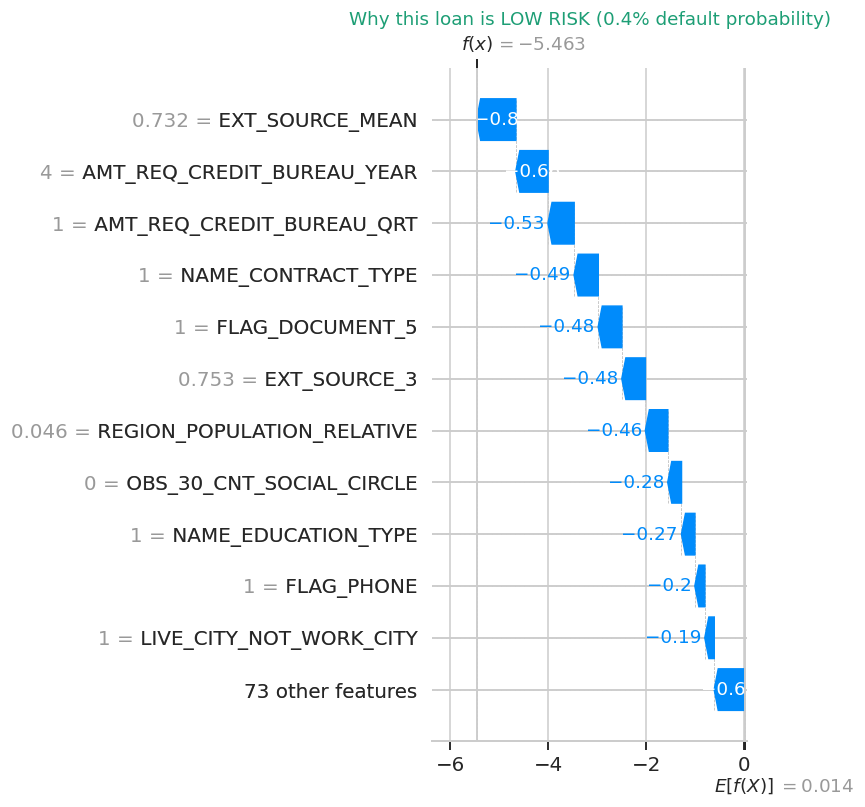

In [9]:
# ── CELL 9: Waterfall plot — LOW RISK applicant ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(shap_values[low_risk_idx], max_display=12, show=False)
plt.title(f'Why this loan is LOW RISK ({probs_sample[low_risk_idx]*100:.1f}% default probability)',
          fontsize=12, color='#1D9E75')
plt.tight_layout()
plt.savefig('/content/shap_low_risk.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 5 — Plain-English Explanation Generator

This is what makes your app feel like a real product — translating SHAP numbers
into sentences a loan officer (or customer) can actually understand.

In [10]:
# ── CELL 10: Plain-English explanation function ────────────────────────────
# Human-readable names + direction of "bad" for each feature
FEATURE_LABELS = {
    'EXT_SOURCE_1': 'External credit score 1',
    'EXT_SOURCE_2': 'External credit score 2',
    'EXT_SOURCE_3': 'External credit score 3',
    'EXT_SOURCE_MEAN': 'Average external credit score',
    'EXT_SOURCE_MIN': 'Worst external credit score',
    'DEBT_TO_INCOME': 'Debt-to-income ratio',
    'CREDIT_TO_INCOME': 'Loan-to-income ratio',
    'ANNUITY_TO_CREDIT': 'Repayment-to-loan ratio',
    'AGE_YEARS': 'Applicant age',
    'EMPLOYMENT_YEARS': 'Years employed',
    'EMPLOYMENT_TO_AGE': 'Employment stability',
    'INCOME_PER_PERSON': 'Income per family member',
    'LOAN_TO_VALUE': 'Loan-to-value ratio',
    'DOCS_SUBMITTED': 'Documents submitted',
    'IS_YOUNG_APPLICANT': 'Young applicant flag',
    'DAYS_BIRTH': 'Applicant age',
    'DAYS_EMPLOYED': 'Employment history',
    'AMT_CREDIT': 'Loan amount',
    'AMT_INCOME_TOTAL': 'Annual income',
    'AMT_ANNUITY': 'Monthly repayment amount',
    'REGION_RATING_CLIENT_W_CITY': 'Region risk rating',
}

def explain_prediction(shap_explanation, feature_names, top_n=5):
    """
    Converts a SHAP explanation into plain-English sentences.

    Parameters
    ----------
    shap_explanation : shap.Explanation for a single prediction
    feature_names    : list of feature column names
    top_n            : number of top factors to explain

    Returns
    -------
    list of explanation strings
    """
    values = shap_explanation.values
    data   = shap_explanation.data

    # Sort by absolute impact
    order = np.argsort(np.abs(values))[::-1][:top_n]

    explanations = []
    for idx in order:
        feat = feature_names[idx]
        shap_val = values[idx]
        feat_val = data[idx]
        label = FEATURE_LABELS.get(feat, feat)

        direction = 'increased' if shap_val > 0 else 'decreased'
        impact = 'risk'

        # Format the feature value nicely
        if 'RATIO' in feat or feat in ['DEBT_TO_INCOME','CREDIT_TO_INCOME','ANNUITY_TO_CREDIT',
                                         'LOAN_TO_VALUE','EMPLOYMENT_TO_AGE']:
            val_str = f'{feat_val:.2f}'
        elif feat in ['AGE_YEARS','EMPLOYMENT_YEARS']:
            val_str = f'{feat_val:.0f} years'
        elif 'EXT_SOURCE' in feat:
            val_str = f'{feat_val:.2f}'
        elif feat in ['AMT_CREDIT','AMT_INCOME_TOTAL','AMT_ANNUITY']:
            val_str = f'₹{feat_val:,.0f}'
        else:
            val_str = f'{feat_val:.2f}'

        explanations.append(
            f'{label} = {val_str} → {direction} default {impact} '
            f'(SHAP impact: {shap_val:+.3f})'
        )

    return explanations


print('═' * 70)
print(f'HIGH RISK applicant ({probs_sample[high_risk_idx]*100:.1f}% default probability):')
print('═' * 70)
for line in explain_prediction(shap_values[high_risk_idx], SELECTED_FEATURES):
    print(f'  • {line}')

print(f'\n{"═" * 70}')
print(f'LOW RISK applicant ({probs_sample[low_risk_idx]*100:.1f}% default probability):')
print('═' * 70)
for line in explain_prediction(shap_values[low_risk_idx], SELECTED_FEATURES):
    print(f'  • {line}')

══════════════════════════════════════════════════════════════════════
HIGH RISK applicant (63.1% default probability):
══════════════════════════════════════════════════════════════════════
  • AMT_REQ_CREDIT_BUREAU_YEAR = 3.00 → decreased default risk (SHAP impact: -0.611)
  • NAME_EDUCATION_TYPE = 2.00 → increased default risk (SHAP impact: +0.393)
  • Average external credit score = 0.35 → increased default risk (SHAP impact: +0.372)
  • OCCUPATION_TYPE = 12.00 → increased default risk (SHAP impact: +0.280)
  • External credit score 3 = 0.19 → increased default risk (SHAP impact: +0.269)

══════════════════════════════════════════════════════════════════════
LOW RISK applicant (0.4% default probability):
══════════════════════════════════════════════════════════════════════
  • Average external credit score = 0.73 → decreased default risk (SHAP impact: -0.800)
  • AMT_REQ_CREDIT_BUREAU_YEAR = 4.00 → decreased default risk (SHAP impact: -0.658)
  • AMT_REQ_CREDIT_BUREAU_QRT = 1.00 →

---
## Step 6 — Business Impact Calculation

Recruiters love numbers in ₹. Let's calculate how much money the model could save
if a bank used it to flag high-risk loans before approval.

In [11]:
# ── CELL 11: Business impact ────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

# Get predictions on full test set
test_probs = model.predict_proba(X_test)[:, 1]
test_preds = model.predict(X_test)

cm = confusion_matrix(y_test, test_preds)
tn, fp, fn, tp = cm.ravel()

# Average loan amount in the dataset
avg_loan_amount = df['AMT_CREDIT'].mean()

# Assumption: if a default is caught (True Positive), bank avoids the loss
# Typical recovery rate on defaulted loans is ~30%, so loss = 70% of loan amount
loss_rate = 0.70

prevented_loss = tp * avg_loan_amount * loss_rate
missed_loss    = fn * avg_loan_amount * loss_rate

# Cost of false positives — good customers wrongly denied (lost interest revenue)
avg_annual_interest = df['AMT_ANNUITY'].mean() * 0.3   # rough interest portion
opportunity_cost = fp * avg_annual_interest

print('═' * 60)
print('BUSINESS IMPACT — On Test Set (61,503 loans)')
print('═' * 60)
print(f'\nAverage loan amount        : ₹{avg_loan_amount:,.0f}')
print(f'Assumed loss rate on default: {loss_rate*100:.0f}%')
print(f'\nDefaults correctly caught   : {tp:,} loans')
print(f'  → Estimated loss prevented: ₹{prevented_loss:,.0f}')
print(f'\nDefaults missed             : {fn:,} loans')
print(f'  → Estimated loss exposure : ₹{missed_loss:,.0f}')
print(f'\nGood loans wrongly flagged  : {fp:,} loans')
print(f'  → Estimated opportunity cost: ₹{opportunity_cost:,.0f} (lost annual interest)')
print(f'\nNET ESTIMATED VALUE         : ₹{prevented_loss - opportunity_cost:,.0f}')
print('\n(Scale this up: test set is 20% of data, so multiply by 5 for full dataset)')
print(f'Full-dataset estimated value: ₹{(prevented_loss - opportunity_cost)*5:,.0f}')

════════════════════════════════════════════════════════════
BUSINESS IMPACT — On Test Set (61,503 loans)
════════════════════════════════════════════════════════════

Average loan amount        : ₹599,026
Assumed loss rate on default: 70%

Defaults correctly caught   : 222 loans
  → Estimated loss prevented: ₹93,088,640

Defaults missed             : 4,743 loans
  → Estimated loss exposure : ₹1,988,826,222

Good loans wrongly flagged  : 392 loans
  → Estimated opportunity cost: ₹3,187,958 (lost annual interest)

NET ESTIMATED VALUE         : ₹89,900,682

(Scale this up: test set is 20% of data, so multiply by 5 for full dataset)
Full-dataset estimated value: ₹449,503,411


---
## Step 7 — Save SHAP Artefacts for the App

In [12]:
# ── CELL 12: Save everything needed for Week 4 app ──────────────────────────
import os

# Save the explainer object itself (so the app doesn't need to rebuild it)
EXPLAINER_PATH = '/content/drive/MyDrive/shap_explainer.pkl'
with open(EXPLAINER_PATH, 'wb') as f:
    pickle.dump(explainer, f)

# Save feature labels dict for plain-English explanations
LABELS_PATH = '/content/drive/MyDrive/feature_labels.pkl'
with open(LABELS_PATH, 'wb') as f:
    pickle.dump(FEATURE_LABELS, f)

print(f'✓ Explainer saved: {EXPLAINER_PATH}')
print(f'✓ Labels saved   : {LABELS_PATH}')
print(f'\nAll artefacts ready for Week 4 Streamlit app:')
print(f'  - xgb_credit_risk.pkl')
print(f'  - selected_features.pkl')
print(f'  - shap_explainer.pkl')
print(f'  - feature_labels.pkl')

✓ Explainer saved: /content/drive/MyDrive/shap_explainer.pkl
✓ Labels saved   : /content/drive/MyDrive/feature_labels.pkl

All artefacts ready for Week 4 Streamlit app:
  - xgb_credit_risk.pkl
  - selected_features.pkl
  - shap_explainer.pkl
  - feature_labels.pkl


---
## ✅ Week 3 Complete!

| What you did | Output |
|---|---|
| Built SHAP TreeExplainer | Fast, exact for XGBoost |
| Global feature importance | Beeswarm + bar charts |
| Individual explanations | High-risk vs low-risk waterfall plots |
| Plain-English generator | `explain_prediction()` function |
| Business impact | ₹ value calculation |
| Saved artefacts | Explainer + labels for the app |

---
### Git commits to make now:
```
git add notebooks/week3_colab.ipynb
git commit -m "feat: global SHAP feature importance analysis"

git commit -m "feat: SHAP waterfall plots for individual predictions"

git commit -m "feat: plain-english explanation generator + business impact calculation"
```

### Next: Week 4 — Streamlit App
- Build the interactive UI
- Embed SHAP waterfall plots
- Deploy on Hugging Face Spaces